# Benchmark Uni-Mol: MSI con embeddings 3D

## Motivacion

El benchmark anterior (`benchmark.ipynb`) demostro que:

- **MSI domina en propiedades cuanticas** (QM9, QM8) — norm 0.623
- **MSI falla en propiedades experimentales** (ESOL, FreeSolv, Lipo) — norm 1.076 (peor que azar)
- La causa: las **correlaciones cruzadas** de la covarianza capturan patrones electronicos pero introducen ruido para propiedades macroscopicas

**Hipotesis:** El problema no es Mahalanobis, sino el embedding. mol2vec es puramente topologico (2D). Las propiedades experimentales (solubilidad, lipofilicidad) dependen de la **geometria 3D** que mol2vec no codifica.

**Solucion propuesta:** Reemplazar mol2vec (300D, 2D) por [Uni-Mol](https://github.com/deepmodeling/Uni-Mol) (512D, 3D-aware), preentrenado sobre 209M conformaciones moleculares.

### Metodos a comparar

| Metodo | Embedding | Dimension | Similitud |
|--------|-----------|-----------|-----------|
| MSI_mol2vec | mol2vec | 300D | Angulo de Mahalanobis |
| MSI_unimol | Uni-Mol | 512D | Angulo de Mahalanobis |
| MSI_hybrid | mol2vec + Uni-Mol | 812D | Angulo de Mahalanobis |
| Cos_mol2vec | mol2vec | 300D | Coseno estandar |
| Cos_unimol | Uni-Mol | 512D | Coseno estandar |
| TSI | Morgan FP (2048 bits) | — | Tanimoto |

In [5]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Modulo propio: MSI con Uni-Mol
from unimol_msi import (
    generate_unimol_vectors,
    compute_theta,
    cosine_similarity,
    build_hybrid_vectors,
    load_mol2vec_results,
    get_mol2vec_paths,
    REGULARIZATION_LAMBDA,
    UNIMOL_DIM,
    MOL2VEC_DIM,
)

sns.set_theme(style='white', font_scale=1.1)
print('Imports completados.')

Imports completados.


In [6]:
# ---- Rutas ----
DATA_DIR          = 'data'
BENCHMARK_DIR     = os.path.join(DATA_DIR, 'benchmark')
MOL2VEC_OUTPUT    = 'output_benchmark'       # Resultados existentes de mol2vec
UNIMOL_OUTPUT     = 'output_unimol'          # Nuevos resultados de Uni-Mol
os.makedirs(UNIMOL_OUTPUT, exist_ok=True)

# ---- Parametros ----
N_BOOT      = 10_000
RANDOM_SEED = 42
BATCH_SIZE  = 64    # Batch size para Uni-Mol (ajustar segun RAM/GPU)

# ---- Uni-Mol config ----
UNIMOL_MODEL  = 'unimolv1'   # 'unimolv1' o 'unimolv2'
USE_CUDA      = True          # Se desactiva automaticamente si no hay GPU

# ---- Control de datasets ----
# QM9 tiene ~127k moleculas y tarda ~7 horas en CPU.
# Pon SKIP_QM9 = False si quieres incluirlo (o si tienes GPU).
SKIP_QM9 = True

print(f'Directorio mol2vec: {MOL2VEC_OUTPUT}')
print(f'Directorio Uni-Mol: {UNIMOL_OUTPUT}')
print(f'Modelo Uni-Mol:     {UNIMOL_MODEL}')
print(f'Skip QM9:           {SKIP_QM9}')
if SKIP_QM9:
    print('  (QM9 se excluye por tiempo de computo. Cambia SKIP_QM9=False para incluirlo)')

Directorio mol2vec: output_benchmark
Directorio Uni-Mol: output_unimol
Modelo Uni-Mol:     unimolv1
Skip QM9:           True
  (QM9 se excluye por tiempo de computo. Cambia SKIP_QM9=False para incluirlo)


---
## Seccion 1 — Datasets

Identicos al benchmark original. Cada dataset tiene:
- **Molecula de referencia** en la fila 0
- **Propiedades medidas** para validacion
- **n_values**: tamaños de Top-N a evaluar

In [7]:
BENCHMARK_DATASETS = [

    # ===== QM9: propiedades cuanticas =====
    {
        "name": "qm9_aniline",
        "filename": os.path.join(DATA_DIR, "qm9_anilin.csv"),
        "properties": {
            "gap":   ("$E_{gap}$", "$E_h$"),
            "homo":  ("HOMO", "$E_h$"),
            "lumo":  ("LUMO", "$E_h$"),
            "mu":    ("Dipolo $\\mu$", "D"),
            "alpha": ("Polarizabilidad $\\alpha$", "$Bohr^3$"),
        },
        "dataset_label": "QM9",
        "reference_label": "Anilina",
        "n_values": [10, 25, 50, 100, 250],
    },
    {
        "name": "qm9_pyridine",
        "filename": os.path.join(BENCHMARK_DIR, "qm9_pyridine.csv"),
        "properties": {
            "gap":  ("$E_{gap}$", "$E_h$"),
            "homo": ("HOMO", "$E_h$"),
            "lumo": ("LUMO", "$E_h$"),
            "mu":   ("Dipolo $\\mu$", "D"),
        },
        "dataset_label": "QM9",
        "reference_label": "Piridina",
        "n_values": [10, 25, 50, 100, 250],
    },

    # ===== QM8: espectros electronicos =====
    {
        "name": "qm8_aniline",
        "filename": os.path.join(BENCHMARK_DIR, "qm8_aniline.csv"),
        "properties": {
            "E1-CC2": ("E1 excitacion (CC2)", "$E_h$"),
            "E2-CC2": ("E2 excitacion (CC2)", "$E_h$"),
            "E1-CAM": ("E1 excitacion (CAM)", "$E_h$"),
        },
        "dataset_label": "QM8",
        "reference_label": "Anilina",
        "n_values": [10, 25, 50, 100, 250],
    },
    {
        "name": "qm8_pyridine",
        "filename": os.path.join(BENCHMARK_DIR, "qm8_pyridine.csv"),
        "properties": {
            "E1-CC2": ("E1 excitacion (CC2)", "$E_h$"),
            "E2-CC2": ("E2 excitacion (CC2)", "$E_h$"),
            "E1-CAM": ("E1 excitacion (CAM)", "$E_h$"),
        },
        "dataset_label": "QM8",
        "reference_label": "Piridina",
        "n_values": [10, 25, 50, 100, 250],
    },
    {
        "name": "qm8_phenol",
        "filename": os.path.join(BENCHMARK_DIR, "qm8_phenol.csv"),
        "properties": {
            "E1-CC2": ("E1 excitacion (CC2)", "$E_h$"),
            "E2-CC2": ("E2 excitacion (CC2)", "$E_h$"),
            "E1-CAM": ("E1 excitacion (CAM)", "$E_h$"),
        },
        "dataset_label": "QM8",
        "reference_label": "Fenol",
        "n_values": [10, 25, 50, 100, 250],
    },

    # ===== ESOL: solubilidad acuosa =====
    {
        "name": "esol_caffeine",
        "filename": os.path.join(BENCHMARK_DIR, "esol_caffeine.csv"),
        "properties": {"logS": ("Solubilidad (logS)", "log mol/L")},
        "dataset_label": "ESOL",
        "reference_label": "Cafeina",
        "n_values": [10, 25, 50, 100],
    },
    {
        "name": "esol_naphthalene",
        "filename": os.path.join(BENCHMARK_DIR, "esol_naphthalene.csv"),
        "properties": {"logS": ("Solubilidad (logS)", "log mol/L")},
        "dataset_label": "ESOL",
        "reference_label": "Naftaleno",
        "n_values": [10, 25, 50, 100],
    },

    # ===== FreeSolv: energia libre de hidratacion =====
    {
        "name": "freesolv_toluene",
        "filename": os.path.join(BENCHMARK_DIR, "freesolv_toluene.csv"),
        "properties": {"hydration_free_energy": ("$\\Delta G_{hyd}$", "kcal/mol")},
        "dataset_label": "FreeSolv",
        "reference_label": "Tolueno",
        "n_values": [10, 25, 50],
    },
    {
        "name": "freesolv_ethanol",
        "filename": os.path.join(BENCHMARK_DIR, "freesolv_ethanol.csv"),
        "properties": {"hydration_free_energy": ("$\\Delta G_{hyd}$", "kcal/mol")},
        "dataset_label": "FreeSolv",
        "reference_label": "Etanol",
        "n_values": [10, 25, 50],
    },

    # ===== Lipophilicity: logD =====
    {
        "name": "lipo_diclofenac",
        "filename": os.path.join(BENCHMARK_DIR, "lipo_diclofenac.csv"),
        "properties": {"logD": ("logD (pH 7.4)", "")},
        "dataset_label": "Lipophilicity",
        "reference_label": "Diclofenac",
        "n_values": [10, 25, 50, 100],
    },
    {
        "name": "lipo_naproxen",
        "filename": os.path.join(BENCHMARK_DIR, "lipo_naproxen.csv"),
        "properties": {"logD": ("logD (pH 7.4)", "")},
        "dataset_label": "Lipophilicity",
        "reference_label": "Naproxeno",
        "n_values": [10, 25, 50, 100],
    },
]

# Resumen
print(f'{len(BENCHMARK_DATASETS)} datasets configurados:')
for ds in BENCHMARK_DATASETS:
    props = list(ds['properties'].keys())
    print(f'  {ds["dataset_label"]:>14s} / {ds["reference_label"]:<12s}  '
          f'propiedades: {props}')

11 datasets configurados:
             QM9 / Anilina       propiedades: ['gap', 'homo', 'lumo', 'mu', 'alpha']
             QM9 / Piridina      propiedades: ['gap', 'homo', 'lumo', 'mu']
             QM8 / Anilina       propiedades: ['E1-CC2', 'E2-CC2', 'E1-CAM']
             QM8 / Piridina      propiedades: ['E1-CC2', 'E2-CC2', 'E1-CAM']
             QM8 / Fenol         propiedades: ['E1-CC2', 'E2-CC2', 'E1-CAM']
            ESOL / Cafeina       propiedades: ['logS']
            ESOL / Naftaleno     propiedades: ['logS']
        FreeSolv / Tolueno       propiedades: ['hydration_free_energy']
        FreeSolv / Etanol        propiedades: ['hydration_free_energy']
   Lipophilicity / Diclofenac    propiedades: ['logD']
   Lipophilicity / Naproxeno     propiedades: ['logD']


---
## Seccion 2 — Cargar resultados existentes de mol2vec

Reutilizamos los resultados del benchmark anterior (`benchmark.ipynb`).
De cada dataset necesitamos:
- **DataFrame de resultados**: SMILES, propiedades, theta (MSI), TSI, coseno
- **Vectores 300D**: embeddings mol2vec para recalcular theta con diferentes parametros

In [8]:
mol2vec_data = {}
missing = []

for ds in BENCHMARK_DATASETS:
    result = load_mol2vec_results(ds, output_dir=MOL2VEC_OUTPUT)

    if result is None:
        missing.append(ds['name'])
        continue

    mol2vec_data[ds['name']] = {
        'df': result['df'],                # DataFrame con smiles, propiedades, theta, TSI, coseno
        'vectors_300d': result['vectors_300d'],  # (N, 300) embeddings mol2vec
        'config': ds,
        'paths': result['paths'],
    }

    n_mol = len(result['df'])
    print(f'  {ds["dataset_label"]:>14s} / {ds["reference_label"]:<12s}: '
          f'{n_mol:>7,} moleculas cargadas')

if missing:
    print(f'\nADVERTENCIA: {len(missing)} datasets sin resultados mol2vec:')
    for m in missing:
        print(f'  - {m}')
    print('Ejecuta benchmark.ipynb primero para generar los resultados.')
else:
    print(f'\nTodos los {len(mol2vec_data)} datasets cargados correctamente.')

             QM9 / Anilina     : 127,537 moleculas cargadas
             QM9 / Piridina    : 127,537 moleculas cargadas
             QM8 / Anilina     :  21,084 moleculas cargadas
             QM8 / Piridina    :  21,084 moleculas cargadas
             QM8 / Fenol       :  21,084 moleculas cargadas
            ESOL / Cafeina     :   1,093 moleculas cargadas
            ESOL / Naftaleno   :   1,093 moleculas cargadas
        FreeSolv / Tolueno     :     598 moleculas cargadas
        FreeSolv / Etanol      :     598 moleculas cargadas
   Lipophilicity / Diclofenac  :   4,195 moleculas cargadas
   Lipophilicity / Naproxeno   :   4,195 moleculas cargadas

Todos los 11 datasets cargados correctamente.


---
## Seccion 3 — Generar embeddings Uni-Mol (512D, 3D-aware)

Para cada dataset, extraemos embeddings de 512D usando el token `[CLS]` de Uni-Mol.
El modelo toma SMILES, genera conformaciones 3D con RDKit (ETKDG), y las procesa
con un Transformer SE(3)-equivariante.

**IMPORTANTE:** La primera ejecucion descarga el modelo (~500MB) y extrae los embeddings.
Las ejecuciones siguientes usan cache en disco.

> Si no tienes `unimol_tools` instalado: `pip install unimol-tools`

In [9]:
unimol_vectors = {}
t_total = time.time()

# Ordenar datasets por tamaño (menores primero → resultados rapidos)
sorted_items = sorted(mol2vec_data.items(), key=lambda x: len(x[1]['df']))

# Estimacion de tiempo (~5 mol/s en CPU, ~50 mol/s en GPU)
RATE_ESTIMATE = 5.0  # mol/s en CPU (ajustar si tienes GPU)
total_mol = sum(len(d['df']) for _, d in sorted_items
                if not (SKIP_QM9 and d['config']['dataset_label'] == 'QM9'))
print(f'Moleculas a procesar: {total_mol:,}')
print(f'Tiempo estimado: ~{total_mol / RATE_ESTIMATE / 60:.0f} min (a {RATE_ESTIMATE} mol/s)')
print()

for ds_name, data in sorted_items:
    config = data['config']

    # Saltar QM9 si esta configurado
    if SKIP_QM9 and config['dataset_label'] == 'QM9':
        print(f'  SKIP: {config["dataset_label"]} / {config["reference_label"]} '
              f'({len(data["df"]):,} mol) — SKIP_QM9=True')
        continue

    results_path = data['paths']['results']
    stem = os.path.splitext(os.path.basename(config['filename']))[0]
    out_name = f'{stem}_unimol_512d_vectors.csv'

    n_mol = len(data['df'])
    est_min = n_mol / RATE_ESTIMATE / 60

    print(f'\n{"=" * 60}')
    print(f'  {config["dataset_label"]} / {config["reference_label"]} ({n_mol:,} mol, ~{est_min:.0f} min)')
    print(f'{"=" * 60}')

    try:
        vec_path = generate_unimol_vectors(
            path=results_path,
            output_dir=UNIMOL_OUTPUT,
            output_name=out_name,
            batch_size=BATCH_SIZE,
            model_name=UNIMOL_MODEL,
            use_cuda=USE_CUDA,
        )

        vecs = pd.read_csv(vec_path).values.astype(np.float64)
        unimol_vectors[ds_name] = vecs

        # Verificar alineacion con mol2vec
        n_m2v = len(data['vectors_300d'])
        if vecs.shape[0] != n_m2v:
            print(f'  ADVERTENCIA: Desalineacion! Uni-Mol={vecs.shape[0]}, mol2vec={n_m2v}')
        else:
            print(f'  OK: {vecs.shape[0]:,} x {vecs.shape[1]}D, alineado con mol2vec')

    except Exception as e:
        print(f'  ERROR: {e}')
        import traceback; traceback.print_exc()
        print(f'  Saltando {ds_name}...')

elapsed = time.time() - t_total
print(f'\n{"=" * 60}')
print(f'  Uni-Mol: {len(unimol_vectors)}/{len(mol2vec_data)} datasets procesados')
print(f'  Tiempo total: {elapsed/60:.1f} min')
print(f'{"=" * 60}')

Moleculas a procesar: 75,024
Tiempo estimado: ~250 min (a 5.0 mol/s)


  FreeSolv / Tolueno (598 mol, ~2 min)
  [Cache] output_unimol/freesolv_toluene_unimol_512d_vectors.csv (598 moleculas)
  OK: 598 x 512D, alineado con mol2vec

  FreeSolv / Etanol (598 mol, ~2 min)
  [Cache] output_unimol/freesolv_ethanol_unimol_512d_vectors.csv (598 moleculas)
  OK: 598 x 512D, alineado con mol2vec

  ESOL / Cafeina (1,093 mol, ~4 min)
  [Cache] output_unimol/esol_caffeine_unimol_512d_vectors.csv (1,093 moleculas)
  OK: 1,093 x 512D, alineado con mol2vec

  ESOL / Naftaleno (1,093 mol, ~4 min)
  [Cache] output_unimol/esol_naphthalene_unimol_512d_vectors.csv (1,093 moleculas)
  OK: 1,093 x 512D, alineado con mol2vec

  Lipophilicity / Diclofenac (4,195 mol, ~14 min)
  [Cache] output_unimol/lipo_diclofenac_unimol_512d_vectors.csv (4,195 moleculas)
  OK: 4,195 x 512D, alineado con mol2vec

  Lipophilicity / Naproxeno (4,195 mol, ~14 min)
  [Cache] output_unimol/lipo_naproxen_unimol_512d_vectors.csv (4

---
## Seccion 4 — Construir embeddings hibridos (812D)

Concatenamos mol2vec (300D) + Uni-Mol (512D) = 812D.
Ambos se normalizan L2 antes de concatenar para que ninguno domine la covarianza.

In [10]:
hybrid_vectors = {}

for ds_name in unimol_vectors:
    m2v = mol2vec_data[ds_name]['vectors_300d']
    uni = unimol_vectors[ds_name]

    hybrid = build_hybrid_vectors(m2v, uni, normalize=True)
    hybrid_vectors[ds_name] = hybrid

    print(f'  {ds_name:>25s}: mol2vec {m2v.shape} + unimol {uni.shape} '
          f'= hybrid {hybrid.shape}')

print(f'\n{len(hybrid_vectors)} embeddings hibridos construidos.')

           freesolv_toluene: mol2vec (598, 300) + unimol (598, 512) = hybrid (598, 812)
           freesolv_ethanol: mol2vec (598, 300) + unimol (598, 512) = hybrid (598, 812)
              esol_caffeine: mol2vec (1093, 300) + unimol (1093, 512) = hybrid (1093, 812)
           esol_naphthalene: mol2vec (1093, 300) + unimol (1093, 512) = hybrid (1093, 812)
            lipo_diclofenac: mol2vec (4195, 300) + unimol (4195, 512) = hybrid (4195, 812)
              lipo_naproxen: mol2vec (4195, 300) + unimol (4195, 512) = hybrid (4195, 812)
                qm8_aniline: mol2vec (21084, 300) + unimol (21084, 512) = hybrid (21084, 812)
               qm8_pyridine: mol2vec (21084, 300) + unimol (21084, 512) = hybrid (21084, 812)
                 qm8_phenol: mol2vec (21084, 300) + unimol (21084, 512) = hybrid (21084, 812)

9 embeddings hibridos construidos.


---
## Seccion 5 — Benchmark: 6 metodos en competencia directa

Para cada test (dataset, propiedad, N), seleccionamos las Top-N moleculas segun cada metodo
y medimos la desviacion media de sus propiedades respecto a la referencia.
El metodo con **menor desviacion** gana.

### Metodos:

1. **MSI_mol2vec** — Angulo de Mahalanobis en espacio mol2vec 300D (original)
2. **MSI_unimol** — Angulo de Mahalanobis en espacio Uni-Mol 512D
3. **MSI_hybrid** — Angulo de Mahalanobis en espacio concatenado 812D
4. **Cos_unimol** — Coseno estandar en espacio Uni-Mol 512D
5. **Cos_mol2vec** — Coseno estandar en espacio mol2vec 300D
6. **TSI** — Tanimoto sobre Morgan fingerprints (2048 bits)

In [11]:
np.random.seed(RANDOM_SEED)

all_results = []
t0 = time.time()

for ds_name, data in mol2vec_data.items():
    if ds_name not in unimol_vectors:
        continue

    df     = data['df']
    config = data['config']
    m2v    = data['vectors_300d']
    uni    = unimol_vectors[ds_name]
    hyb    = hybrid_vectors[ds_name]

    ds_label  = config['dataset_label']
    ref_label = config['reference_label']
    n_mol     = len(df)

    # --- Calcular thetas y cosenos para Uni-Mol e hibrido ---
    theta_m2v = df['theta'].values                           # Ya calculado
    theta_uni = compute_theta(uni, ref_idx=0)                # Nuevo
    theta_hyb = compute_theta(hyb, ref_idx=0)                # Nuevo
    cos_m2v   = df['embedding_similarity'].values            # Ya calculado
    cos_uni   = cosine_similarity(uni, ref_idx=0)            # Nuevo
    tsi       = df['tanimoto_similarity'].values              # Invariante

    cands_idx = np.arange(1, n_mol)  # Excluir referencia (indice 0)

    for prop_col, (prop_label, prop_unit) in config['properties'].items():
        if prop_col not in df.columns:
            continue

        ref_val = df[prop_col].iloc[0]
        prop_vals = df[prop_col].values
        random_dev = np.abs(prop_vals[cands_idx] - ref_val).mean()

        for N in config['n_values']:
            if N >= len(cands_idx):
                continue

            # --- Top-N por cada metodo ---
            # MSI: menor theta = mas similar
            top_msi_m2v = cands_idx[np.argsort(theta_m2v[cands_idx])[:N]]
            top_msi_uni = cands_idx[np.argsort(theta_uni[cands_idx])[:N]]
            top_msi_hyb = cands_idx[np.argsort(theta_hyb[cands_idx])[:N]]
            # Coseno y TSI: mayor = mas similar
            top_cos_m2v = cands_idx[np.argsort(-cos_m2v[cands_idx])[:N]]
            top_cos_uni = cands_idx[np.argsort(-cos_uni[cands_idx])[:N]]
            top_tsi     = cands_idx[np.argsort(-tsi[cands_idx])[:N]]

            # --- Desviacion media ---
            devs = {
                'MSI_mol2vec': np.abs(prop_vals[top_msi_m2v] - ref_val).mean(),
                'MSI_unimol':  np.abs(prop_vals[top_msi_uni] - ref_val).mean(),
                'MSI_hybrid':  np.abs(prop_vals[top_msi_hyb] - ref_val).mean(),
                'Cos_unimol':  np.abs(prop_vals[top_cos_uni] - ref_val).mean(),
                'Cos_mol2vec': np.abs(prop_vals[top_cos_m2v] - ref_val).mean(),
                'TSI':         np.abs(prop_vals[top_tsi]     - ref_val).mean(),
            }
            winner = min(devs, key=devs.get)

            # --- Bootstrap (solo N <= 25) ---
            p_values = {}
            if N <= 25:
                boot_devs = np.zeros(N_BOOT)
                for b in range(N_BOOT):
                    idx = np.random.choice(cands_idx, size=N, replace=False)
                    boot_devs[b] = np.abs(prop_vals[idx] - ref_val).mean()
                for method_name, dev in devs.items():
                    p_values[f'p_{method_name}'] = (boot_devs <= dev).mean()

            row = {
                'dataset': ds_label, 'reference': ref_label, 'ds_name': ds_name,
                'property': prop_label, 'prop_col': prop_col, 'unit': prop_unit,
                'N': N, 'n_molecules': n_mol - 1,
                'ref_value': ref_val, 'Random_dev': random_dev,
                'winner': winner,
            }

            # Agregar desviaciones y normalizadas
            for method_name, dev in devs.items():
                row[f'{method_name}_dev'] = dev
                row[f'{method_name}_norm'] = dev / random_dev if random_dev > 0 else np.nan

            row.update(p_values)
            all_results.append(row)

bench_df = pd.DataFrame(all_results)
elapsed = time.time() - t0
print(f'Benchmark completado: {len(bench_df)} tests en {elapsed:.1f}s')
print(f'Datasets evaluados: {bench_df["ds_name"].nunique()}')
print(f'Propiedades: {bench_df["property"].nunique()}')

Benchmark completado: 67 tests en 40.9s
Datasets evaluados: 9
Propiedades: 6


---
## Seccion 6 — Scorecard global: Quien gana?

Contamos cuantos tests gana cada metodo.

  SCORECARD GLOBAL — Victorias por metodo
     MSI_mol2vec:  12/67 ( 17.9%)  ████████
      MSI_unimol:   6/67 (  9.0%)  ████
      MSI_hybrid:   5/67 (  7.5%)  ███
      Cos_unimol:  13/67 ( 19.4%)  █████████
     Cos_mol2vec:  22/67 ( 32.8%)  ████████████████
             TSI:   9/67 ( 13.4%)  ██████


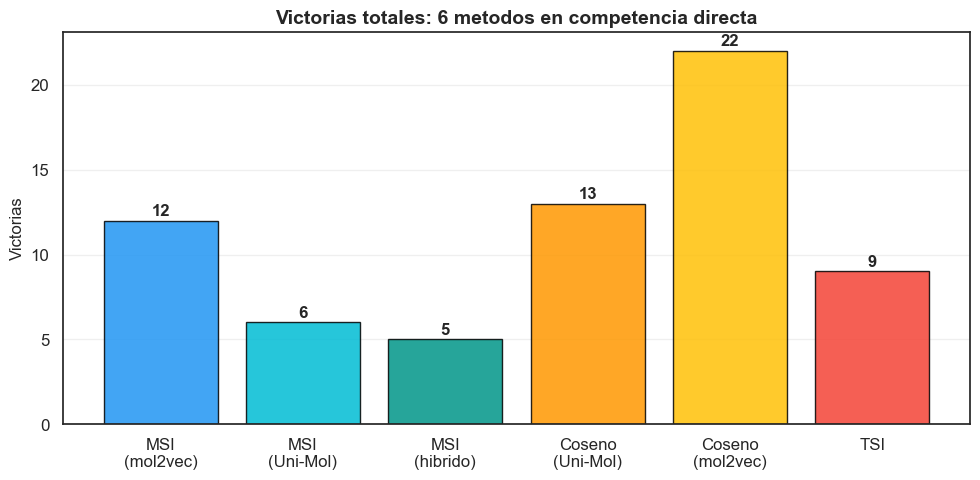

In [12]:
METODOS = ['MSI_mol2vec', 'MSI_unimol', 'MSI_hybrid', 'Cos_unimol', 'Cos_mol2vec', 'TSI']
COLORES = {
    'MSI_mol2vec': '#2196F3',
    'MSI_unimol':  '#00BCD4',
    'MSI_hybrid':  '#009688',
    'Cos_unimol':  '#FF9800',
    'Cos_mol2vec': '#FFC107',
    'TSI':         '#F44336',
}
LABELS = {
    'MSI_mol2vec': 'MSI\n(mol2vec)',
    'MSI_unimol':  'MSI\n(Uni-Mol)',
    'MSI_hybrid':  'MSI\n(hibrido)',
    'Cos_unimol':  'Coseno\n(Uni-Mol)',
    'Cos_mol2vec': 'Coseno\n(mol2vec)',
    'TSI':         'TSI',
}

wins = bench_df['winner'].value_counts()
total = len(bench_df)

print('=' * 70)
print('  SCORECARD GLOBAL — Victorias por metodo')
print('=' * 70)
for m in METODOS:
    n = wins.get(m, 0)
    pct = 100 * n / total
    bar = '█' * int(pct / 2)
    print(f'  {m:>14s}: {n:>3d}/{total} ({pct:>5.1f}%)  {bar}')
print('=' * 70)

# --- Grafico de barras ---
fig, ax = plt.subplots(figsize=(10, 5))
conteos = [wins.get(m, 0) for m in METODOS]
labels = [LABELS[m] for m in METODOS]
colors = [COLORES[m] for m in METODOS]

bars = ax.bar(labels, conteos, color=colors, alpha=0.85, edgecolor='black')
for bar, val in zip(bars, conteos):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Victorias', fontsize=12)
ax.set_title('Victorias totales: 6 metodos en competencia directa', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Desviacion normalizada promedio

Cada barra muestra `desviacion_metodo / desviacion_aleatoria`.
Menor = mejor. La linea gris (1.0) es el baseline aleatorio.

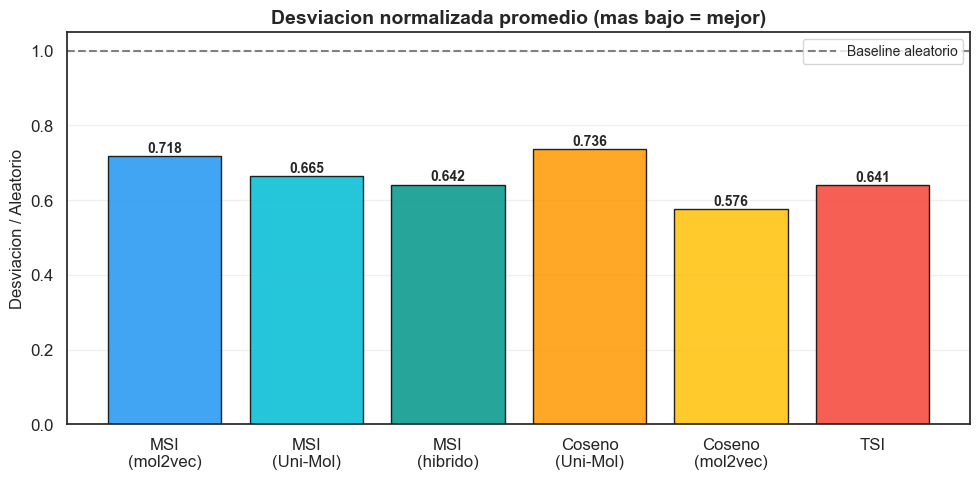

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

mean_norms = [bench_df[f'{m}_norm'].mean() for m in METODOS]
labels = [LABELS[m] for m in METODOS]
colors = [COLORES[m] for m in METODOS]

bars = ax.bar(labels, mean_norms, color=colors, alpha=0.85, edgecolor='black')
ax.axhline(y=1.0, color='gray', ls='--', lw=1.5, label='Baseline aleatorio')

for bar, val in zip(bars, mean_norms):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Desviacion / Aleatorio', fontsize=12)
ax.set_title('Desviacion normalizada promedio (mas bajo = mejor)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
## Seccion 7 — La pregunta clave: Cuantico vs Experimental

Esta es la comparacion mas importante. Si Uni-Mol resuelve el problema de MSI
en propiedades experimentales, deberiamos ver:

1. **Cuantico**: MSI_mol2vec y MSI_unimol ambos buenos (embeddings redundantes)
2. **Experimental**: MSI_unimol **mucho mejor** que MSI_mol2vec (info 3D critica)

  COMPARACION: CUANTICO vs EXPERIMENTAL
  (QM9 excluido — solo QM8 en cuantico)

  --- CUANTICO (45 tests) ---
       MSI_mol2vec:  12 victorias ( 26.7%)  norm=0.543
        MSI_unimol:   5 victorias ( 11.1%)  norm=0.567
        MSI_hybrid:   4 victorias (  8.9%)  norm=0.478
        Cos_unimol:   4 victorias (  8.9%)  norm=0.747
       Cos_mol2vec:  15 victorias ( 33.3%)  norm=0.442
               TSI:   5 victorias ( 11.1%)  norm=0.548

  --- EXPERIMENTAL (22 tests) ---
       MSI_mol2vec:   0 victorias (  0.0%)  norm=1.076
        MSI_unimol:   1 victorias (  4.5%)  norm=0.865
        MSI_hybrid:   1 victorias (  4.5%)  norm=0.978
        Cos_unimol:   9 victorias ( 40.9%)  norm=0.714
       Cos_mol2vec:   7 victorias ( 31.8%)  norm=0.849
               TSI:   4 victorias ( 18.2%)  norm=0.832



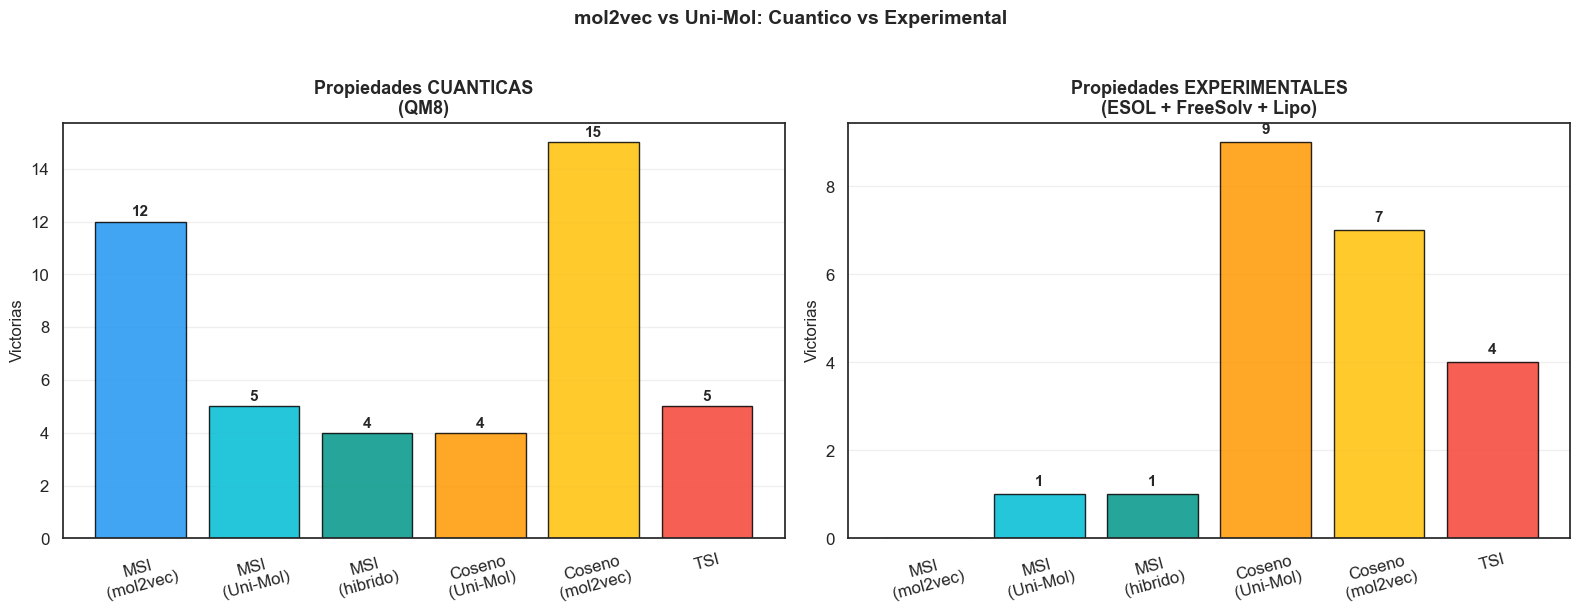

In [14]:
QUANTUM_DS = {'QM9', 'QM8'}
EXPER_DS   = {'ESOL', 'FreeSolv', 'Lipophilicity'}

# Filtrar solo datasets que tienen datos Uni-Mol
available_datasets = set(bench_df['dataset'].unique())
q_mask = bench_df['dataset'].isin(QUANTUM_DS & available_datasets)
e_mask = bench_df['dataset'].isin(EXPER_DS & available_datasets)

print('=' * 70)
print('  COMPARACION: CUANTICO vs EXPERIMENTAL')
if SKIP_QM9:
    print('  (QM9 excluido — solo QM8 en cuantico)')
print('=' * 70)

for label, mask in [('CUANTICO', q_mask),
                    ('EXPERIMENTAL', e_mask)]:
    sub = bench_df[mask]
    total_sub = len(sub)
    if total_sub == 0:
        print(f'\n  --- {label}: sin datos ---')
        continue
    wins_sub = sub['winner'].value_counts()

    print(f'\n  --- {label} ({total_sub} tests) ---')
    for m in METODOS:
        n = wins_sub.get(m, 0)
        pct = 100 * n / total_sub
        norm = sub[f'{m}_norm'].mean()
        print(f'    {m:>14s}: {n:>3d} victorias ({pct:>5.1f}%)  norm={norm:.3f}')

print(f'\n{"=" * 70}')

# --- Grafico lado a lado ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (title, mask) in zip(axes, [
    ('Propiedades CUANTICAS\n(QM8' + ('+QM9' if not SKIP_QM9 else '') + ')', q_mask),
    ('Propiedades EXPERIMENTALES\n(ESOL + FreeSolv + Lipo)', e_mask),
]):
    sub = bench_df[mask]
    wins_sub = sub['winner'].value_counts()
    conteos = [wins_sub.get(m, 0) for m in METODOS]
    labels_plot = [LABELS[m] for m in METODOS]
    colors_plot = [COLORES[m] for m in METODOS]

    bars = ax.bar(labels_plot, conteos, color=colors_plot, alpha=0.85, edgecolor='black')
    for bar, val in zip(bars, conteos):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                    f'{val}', ha='center', fontsize=11, fontweight='bold')

    ax.set_ylabel('Victorias', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('mol2vec vs Uni-Mol: Cuantico vs Experimental',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Desviacion normalizada por grupo

Aqui es donde se ve la diferencia real. En experimental, MSI_unimol deberia
tener una barra **mas baja** que MSI_mol2vec (que estaba por encima de 1.0).

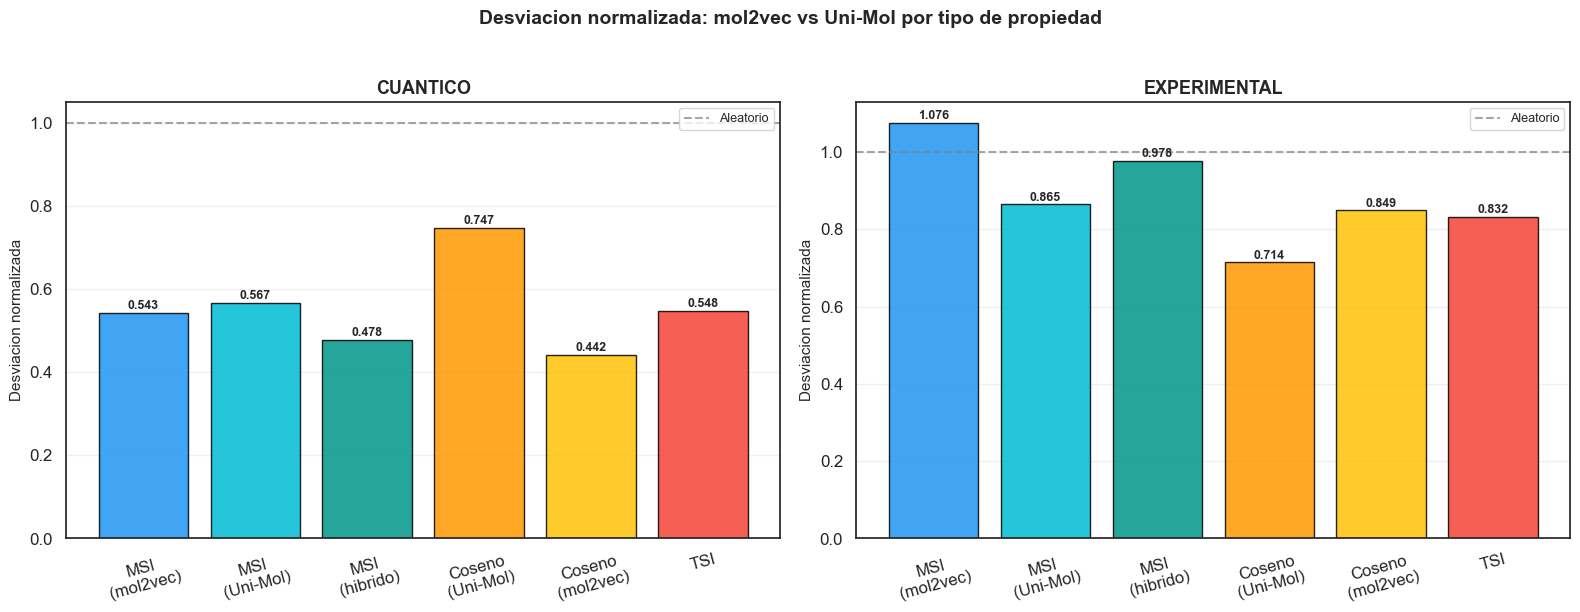

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (title, mask) in zip(axes, [
    ('CUANTICO', q_mask),
    ('EXPERIMENTAL', e_mask),
]):
    sub = bench_df[mask]
    norms = [sub[f'{m}_norm'].mean() for m in METODOS]
    labels_plot = [LABELS[m] for m in METODOS]
    colors_plot = [COLORES[m] for m in METODOS]

    bars = ax.bar(labels_plot, norms, color=colors_plot, alpha=0.85, edgecolor='black')
    ax.axhline(y=1.0, color='gray', ls='--', lw=1.5, alpha=0.7, label='Aleatorio')

    for bar, val in zip(bars, norms):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

    ax.set_ylabel('Desviacion normalizada', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('Desviacion normalizada: mol2vec vs Uni-Mol por tipo de propiedad',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Desglose por dataset individual

In [16]:
pivot = bench_df.groupby(['dataset', 'winner']).size().unstack(fill_value=0)
for m in METODOS:
    if m not in pivot.columns:
        pivot[m] = 0

print('Victorias por dataset:')
display(pivot[METODOS])

Victorias por dataset:


winner,MSI_mol2vec,MSI_unimol,MSI_hybrid,Cos_unimol,Cos_mol2vec,TSI
dataset,,,,,,
ESOL,0,0,0,5,1,2
FreeSolv,0,0,0,2,2,2
Lipophilicity,0,1,1,2,4,0
QM8,12,5,4,4,15,5


---
## Seccion 8 — Sensibilidad a Lambda en espacio Uni-Mol

En el benchmark anterior, MSI_mol2vec experimental mejoro con lambda=1e-2
(norm 1.076 → 0.760). ¿Pasa lo mismo con Uni-Mol? ¿O el embedding 3D
hace que las correlaciones sean utiles incluso para experimental?

In [17]:
LAMBDAS = [0, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1, 0.5, 1.0, 10.0]

print(f'Probando {len(LAMBDAS)} valores de lambda en espacio Uni-Mol...\n')
t0 = time.time()

lambda_results = []

for ds_name, data in mol2vec_data.items():
    if ds_name not in unimol_vectors:
        continue

    config = data['config']
    df = data['df']
    uni = unimol_vectors[ds_name]
    tsi = df['tanimoto_similarity'].values
    prop_vals_dict = {}

    n_mol = len(df)
    cands_idx = np.arange(1, n_mol)

    for lam in LAMBDAS:
        try:
            theta_uni_lam = compute_theta(uni, ref_idx=0, lambda_reg=lam)
        except np.linalg.LinAlgError:
            continue

        for prop_col, (prop_label, prop_unit) in config['properties'].items():
            if prop_col not in df.columns:
                continue

            ref_val = df[prop_col].iloc[0]
            prop_vals = df[prop_col].values
            random_dev = np.abs(prop_vals[cands_idx] - ref_val).mean()

            for N in config['n_values']:
                if N >= len(cands_idx):
                    continue

                top_uni = cands_idx[np.argsort(theta_uni_lam[cands_idx])[:N]]
                top_tsi_idx = cands_idx[np.argsort(-tsi[cands_idx])[:N]]

                uni_dev = np.abs(prop_vals[top_uni] - ref_val).mean()
                tsi_dev = np.abs(prop_vals[top_tsi_idx] - ref_val).mean()

                devs = {'MSI_unimol': uni_dev, 'TSI': tsi_dev}
                winner = min(devs, key=devs.get)

                lambda_results.append({
                    'dataset': config['dataset_label'],
                    'ds_name': ds_name,
                    'property': prop_label,
                    'N': N,
                    'lambda': lam,
                    'MSI_unimol_dev': uni_dev,
                    'MSI_unimol_norm': uni_dev / random_dev if random_dev > 0 else np.nan,
                    'TSI_dev': tsi_dev,
                    'Random_dev': random_dev,
                    'winner': winner,
                })

    print(f'  {config["dataset_label"]:>14s} / {config["reference_label"]:<12s}: completado')

lambda_df = pd.DataFrame(lambda_results)
print(f'\nTotal tests lambda: {len(lambda_df):,} en {time.time()-t0:.1f}s')

Probando 11 valores de lambda en espacio Uni-Mol...

             QM8 / Anilina     : completado
             QM8 / Piridina    : completado
             QM8 / Fenol       : completado
            ESOL / Cafeina     : completado
            ESOL / Naftaleno   : completado
        FreeSolv / Tolueno     : completado
        FreeSolv / Etanol      : completado
   Lipophilicity / Diclofenac  : completado
   Lipophilicity / Naproxeno   : completado

Total tests lambda: 737 en 7.4s


  SENSIBILIDAD A LAMBDA: UNI-MOL — CUANTICO vs EXPERIMENTAL

  --- CUANTICO (QM9+QM8) ---
  Lambda         MSI wins    MSI %       Norm
  ---------------------------------------------
  0                15/45      33.3%      0.572
  1e-07            15/45      33.3%      0.567
  1e-06            15/45      33.3%      0.567
  1e-05            15/45      33.3%      0.567 ◄ default
  1e-04            15/45      33.3%      0.567
  1e-03            15/45      33.3%      0.567
  1e-02            15/45      33.3%      0.570
  1e-01            18/45      40.0%      0.570
  5e-01            18/45      40.0%      0.577
  1e+00            19/45      42.2%      0.573
  1e+01            13/45      28.9%      0.612

  --- EXPERIMENTAL ---
  Lambda         MSI wins    MSI %       Norm
  ---------------------------------------------
  0                10/22      45.5%      0.872
  1e-07            10/22      45.5%      0.864
  1e-06            10/22      45.5%      0.864
  1e-05            10/22      

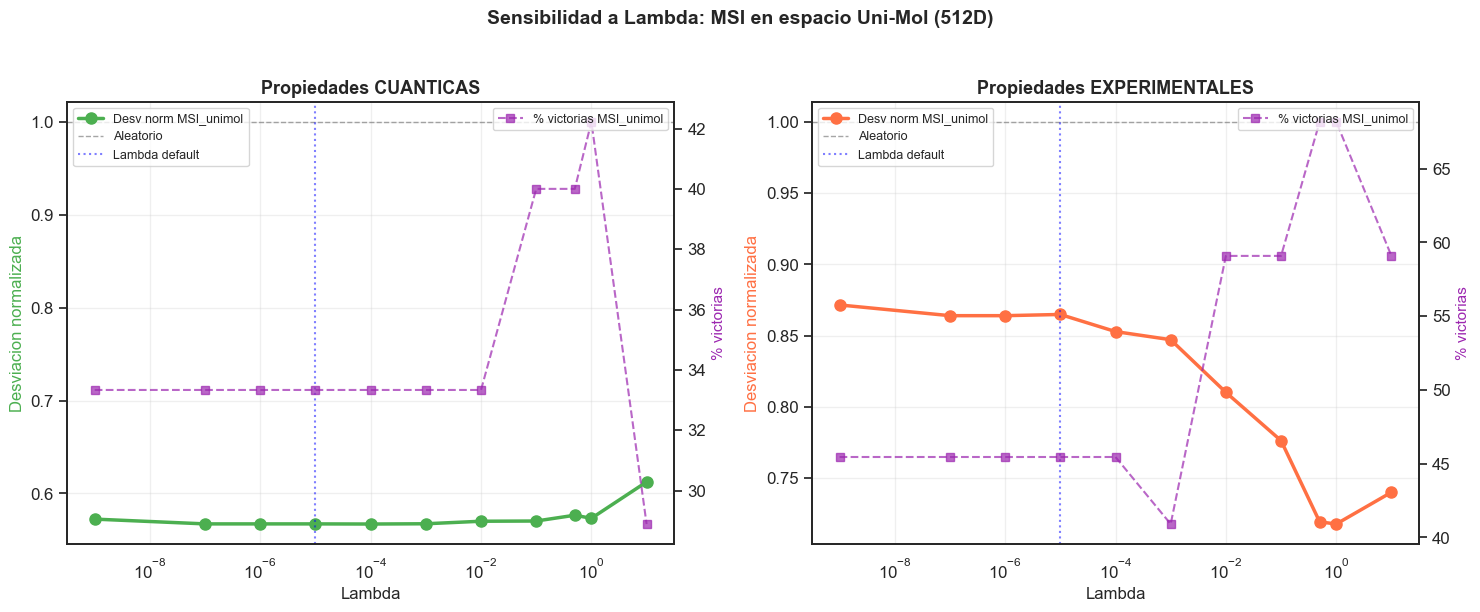

In [18]:
print('=' * 70)
print('  SENSIBILIDAD A LAMBDA: UNI-MOL — CUANTICO vs EXPERIMENTAL')
print('=' * 70)

for group_label, ds_set in [('CUANTICO (QM9+QM8)', QUANTUM_DS),
                              ('EXPERIMENTAL', EXPER_DS)]:
    sub = lambda_df[lambda_df['dataset'].isin(ds_set)]
    print(f'\n  --- {group_label} ---')
    print(f'  {"Lambda":<12s} {"MSI wins":>10s} {"MSI %":>8s} {"Norm":>10s}')
    print(f'  {"-"*45}')

    for lam in LAMBDAS:
        lam_sub = sub[sub['lambda'] == lam]
        if len(lam_sub) == 0:
            continue
        n_wins = (lam_sub['winner'] == 'MSI_unimol').sum()
        total = len(lam_sub)
        pct = 100 * n_wins / total
        norm = lam_sub['MSI_unimol_norm'].mean()
        marker = ' ◄ default' if lam == 1e-5 else ''
        lam_str = f'{lam:.0e}' if lam > 0 else '0'
        print(f'  {lam_str:<12s} {n_wins:>6d}/{total:<4d} {pct:>7.1f}% {norm:>10.3f}{marker}')

print(f'\n{"=" * 70}')

# --- Grafico ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (title, ds_set, color) in zip(axes, [
    ('Propiedades CUANTICAS', QUANTUM_DS, '#4CAF50'),
    ('Propiedades EXPERIMENTALES', EXPER_DS, '#FF7043'),
]):
    sub = lambda_df[lambda_df['dataset'].isin(ds_set)]
    lambdas_plot, norms_plot, wins_plot = [], [], []

    for lam in LAMBDAS:
        lam_sub = sub[sub['lambda'] == lam]
        if len(lam_sub) == 0:
            continue
        lambdas_plot.append(lam if lam > 0 else 1e-9)
        norms_plot.append(lam_sub['MSI_unimol_norm'].mean())
        wins_plot.append(100 * (lam_sub['winner'] == 'MSI_unimol').sum() / len(lam_sub))

    ax.plot(lambdas_plot, norms_plot, 'o-', color=color, lw=2.5, ms=8,
            label='Desv norm MSI_unimol')
    ax.axhline(y=1.0, color='gray', ls='--', lw=1, alpha=0.7, label='Aleatorio')
    ax.axvline(x=1e-5, color='blue', ls=':', lw=1.5, alpha=0.5, label='Lambda default')

    ax.set_xscale('log')
    ax.set_xlabel('Lambda', fontsize=12)
    ax.set_ylabel('Desviacion normalizada', fontsize=12, color=color)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)

    ax2 = ax.twinx()
    ax2.plot(lambdas_plot, wins_plot, 's--', color='#9C27B0', lw=1.5, ms=6,
             alpha=0.7, label='% victorias MSI_unimol')
    ax2.set_ylabel('% victorias', fontsize=11, color='#9C27B0')
    ax2.legend(fontsize=9, loc='upper right')

fig.suptitle('Sensibilidad a Lambda: MSI en espacio Uni-Mol (512D)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Seccion 9 — Comparacion directa: MSI_mol2vec vs MSI_unimol

Test por test, ¿quien gana? Si MSI_unimol mejora en experimental
sin perder en cuantico, el embedding 3D es estrictamente superior.

In [19]:
# Comparar MSI_mol2vec vs MSI_unimol directamente (head-to-head)
bench_df['h2h_winner'] = np.where(
    bench_df['MSI_mol2vec_dev'] < bench_df['MSI_unimol_dev'], 'mol2vec',
    np.where(bench_df['MSI_mol2vec_dev'] > bench_df['MSI_unimol_dev'], 'unimol', 'empate')
)

print('=' * 70)
print('  HEAD-TO-HEAD: MSI_mol2vec vs MSI_unimol')
print('=' * 70)

for label, mask in [('GLOBAL', bench_df.index == bench_df.index),
                    ('CUANTICO', q_mask), ('EXPERIMENTAL', e_mask)]:
    sub = bench_df[mask]
    h2h = sub['h2h_winner'].value_counts()
    total_sub = len(sub)
    n_m2v = h2h.get('mol2vec', 0)
    n_uni = h2h.get('unimol', 0)
    n_tie = h2h.get('empate', 0)

    m2v_norm = sub['MSI_mol2vec_norm'].mean()
    uni_norm = sub['MSI_unimol_norm'].mean()
    diff = m2v_norm - uni_norm

    print(f'\n  {label} ({total_sub} tests):')
    print(f'    mol2vec gana: {n_m2v:>3d} ({100*n_m2v/total_sub:.1f}%)')
    print(f'    Uni-Mol gana: {n_uni:>3d} ({100*n_uni/total_sub:.1f}%)')
    print(f'    Empate:       {n_tie:>3d}')
    print(f'    Norm mol2vec: {m2v_norm:.3f}')
    print(f'    Norm Uni-Mol: {uni_norm:.3f}')
    print(f'    Diferencia:   {diff:+.3f} {"(Uni-Mol mejor)" if diff > 0 else "(mol2vec mejor)"}')

print(f'\n{"=" * 70}')

  HEAD-TO-HEAD: MSI_mol2vec vs MSI_unimol

  GLOBAL (67 tests):
    mol2vec gana:  31 (46.3%)
    Uni-Mol gana:  36 (53.7%)
    Empate:         0
    Norm mol2vec: 0.718
    Norm Uni-Mol: 0.665
    Diferencia:   +0.053 (Uni-Mol mejor)

  CUANTICO (45 tests):
    mol2vec gana:  24 (53.3%)
    Uni-Mol gana:  21 (46.7%)
    Empate:         0
    Norm mol2vec: 0.543
    Norm Uni-Mol: 0.567
    Diferencia:   -0.025 (mol2vec mejor)

  EXPERIMENTAL (22 tests):
    mol2vec gana:   7 (31.8%)
    Uni-Mol gana:  15 (68.2%)
    Empate:         0
    Norm mol2vec: 1.076
    Norm Uni-Mol: 0.865
    Diferencia:   +0.211 (Uni-Mol mejor)



---
## Seccion 10 — Conclusiones

In [20]:
print('=' * 70)
print('  RESUMEN FINAL: mol2vec vs Uni-Mol para MSI')
print('=' * 70)

# 1. Global wins
wins = bench_df['winner'].value_counts()
total = len(bench_df)
print(f'\n  1. VICTORIAS GLOBALES ({total} tests):')
for m in METODOS:
    n = wins.get(m, 0)
    print(f'     {m:>14s}: {n:>3d} ({100*n/total:.1f}%)')

# 2. Per-group norms
print(f'\n  2. DESVIACION NORMALIZADA POR GRUPO:')
print(f'     {"Metodo":<16s} {"Cuantico":>10s} {"Experimental":>14s} {"Global":>8s}')
print(f'     {"-"*50}')
for m in METODOS:
    q_norm = bench_df[q_mask][f'{m}_norm'].mean()
    e_norm = bench_df[e_mask][f'{m}_norm'].mean()
    g_norm = bench_df[f'{m}_norm'].mean()
    print(f'     {m:<16s} {q_norm:>10.3f} {e_norm:>14.3f} {g_norm:>8.3f}')

# 3. Head-to-head
print(f'\n  3. HEAD-TO-HEAD MSI_mol2vec vs MSI_unimol:')
for label, mask in [('Cuantico', q_mask), ('Experimental', e_mask)]:
    sub = bench_df[mask]
    h2h = sub['h2h_winner'].value_counts()
    n_m2v = h2h.get('mol2vec', 0)
    n_uni = h2h.get('unimol', 0)
    total_sub = len(sub)
    print(f'     {label:>14s}: mol2vec {n_m2v}/{total_sub}, '
          f'Uni-Mol {n_uni}/{total_sub}')

print(f'\n{"=" * 70}')
print('  INTERPRETACION:')
print('  ' + '-' * 50)
print('  (Los resultados determinaran si el embedding 3D de')
print('  Uni-Mol resuelve la debilidad de MSI en propiedades')
print('  experimentales, o si el problema es mas fundamental)')
print('=' * 70)

  RESUMEN FINAL: mol2vec vs Uni-Mol para MSI

  1. VICTORIAS GLOBALES (67 tests):
        MSI_mol2vec:  12 (17.9%)
         MSI_unimol:   6 (9.0%)
         MSI_hybrid:   5 (7.5%)
         Cos_unimol:  13 (19.4%)
        Cos_mol2vec:  22 (32.8%)
                TSI:   9 (13.4%)

  2. DESVIACION NORMALIZADA POR GRUPO:
     Metodo             Cuantico   Experimental   Global
     --------------------------------------------------
     MSI_mol2vec           0.543          1.076    0.718
     MSI_unimol            0.567          0.865    0.665
     MSI_hybrid            0.478          0.978    0.642
     Cos_unimol            0.747          0.714    0.736
     Cos_mol2vec           0.442          0.849    0.576
     TSI                   0.548          0.832    0.641

  3. HEAD-TO-HEAD MSI_mol2vec vs MSI_unimol:
           Cuantico: mol2vec 24/45, Uni-Mol 21/45
       Experimental: mol2vec 7/22, Uni-Mol 15/22

  INTERPRETACION:
  --------------------------------------------------
  (Los res